In [14]:
import sys
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336')
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/EM_analyzer')
from line_profiler import profile
import numpy as np
import jax
from wrapt import partial
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'cpu')
from scipy.signal.windows import tukey
import scipy.constants as C
import jax.numpy as jnp
from typing import List, Optional, Tuple, Union
import string
import xarray as xr
from EM_analyzer.fft_backend import fftn,ifftn,fftfreq
from EM_analyzer.pretreat_fields import pad_for_fft,get_norm
from EM_analyzer.Spectral_Maxwell.kgrid import make_k_coordinate_from_r_coordinate,make_r_coordinate_from_k_coordinate
from EM_analyzer.spectrum import get_spectrum_from_field_with_coordinate,get_field_from_spectrum_with_coordinate
from EM_analyzer.rotate_3D import Rotation
from EM_analyzer.plot.plot_2D import plot_2D_spectrum,plot_2D_field

In [2]:
x_coordinate = jnp.linspace(-20,20,1001)
y_coordinate = jnp.linspace(-20,20,1001)
z_coordinate = jnp.array([0])
x,y,z=jnp.meshgrid(x_coordinate,y_coordinate,z_coordinate,indexing='ij')
wavelength=1
wx=8
wy=4
k0=2*jnp.pi/wavelength
Ey=jnp.exp(-x**2/wx**2-y**2/wy**2)*jnp.sin(k0*x)
Ex=jnp.zeros_like(Ey)
Ez=jnp.zeros_like(Ey)
spectrum_peak=C.pi*wx*wy/2

figure size= [18.5 14. ] inch
ax_main position= Bbox(x0=0.24324324324324326, y0=0.10714285714285714, x1=0.6756756756756757, y1=0.6785714285714285)


{'fig': <Figure size 1850x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_panel_top': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>,
 'ax_panel_left': <Axes: xlabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x1467ec171550>}

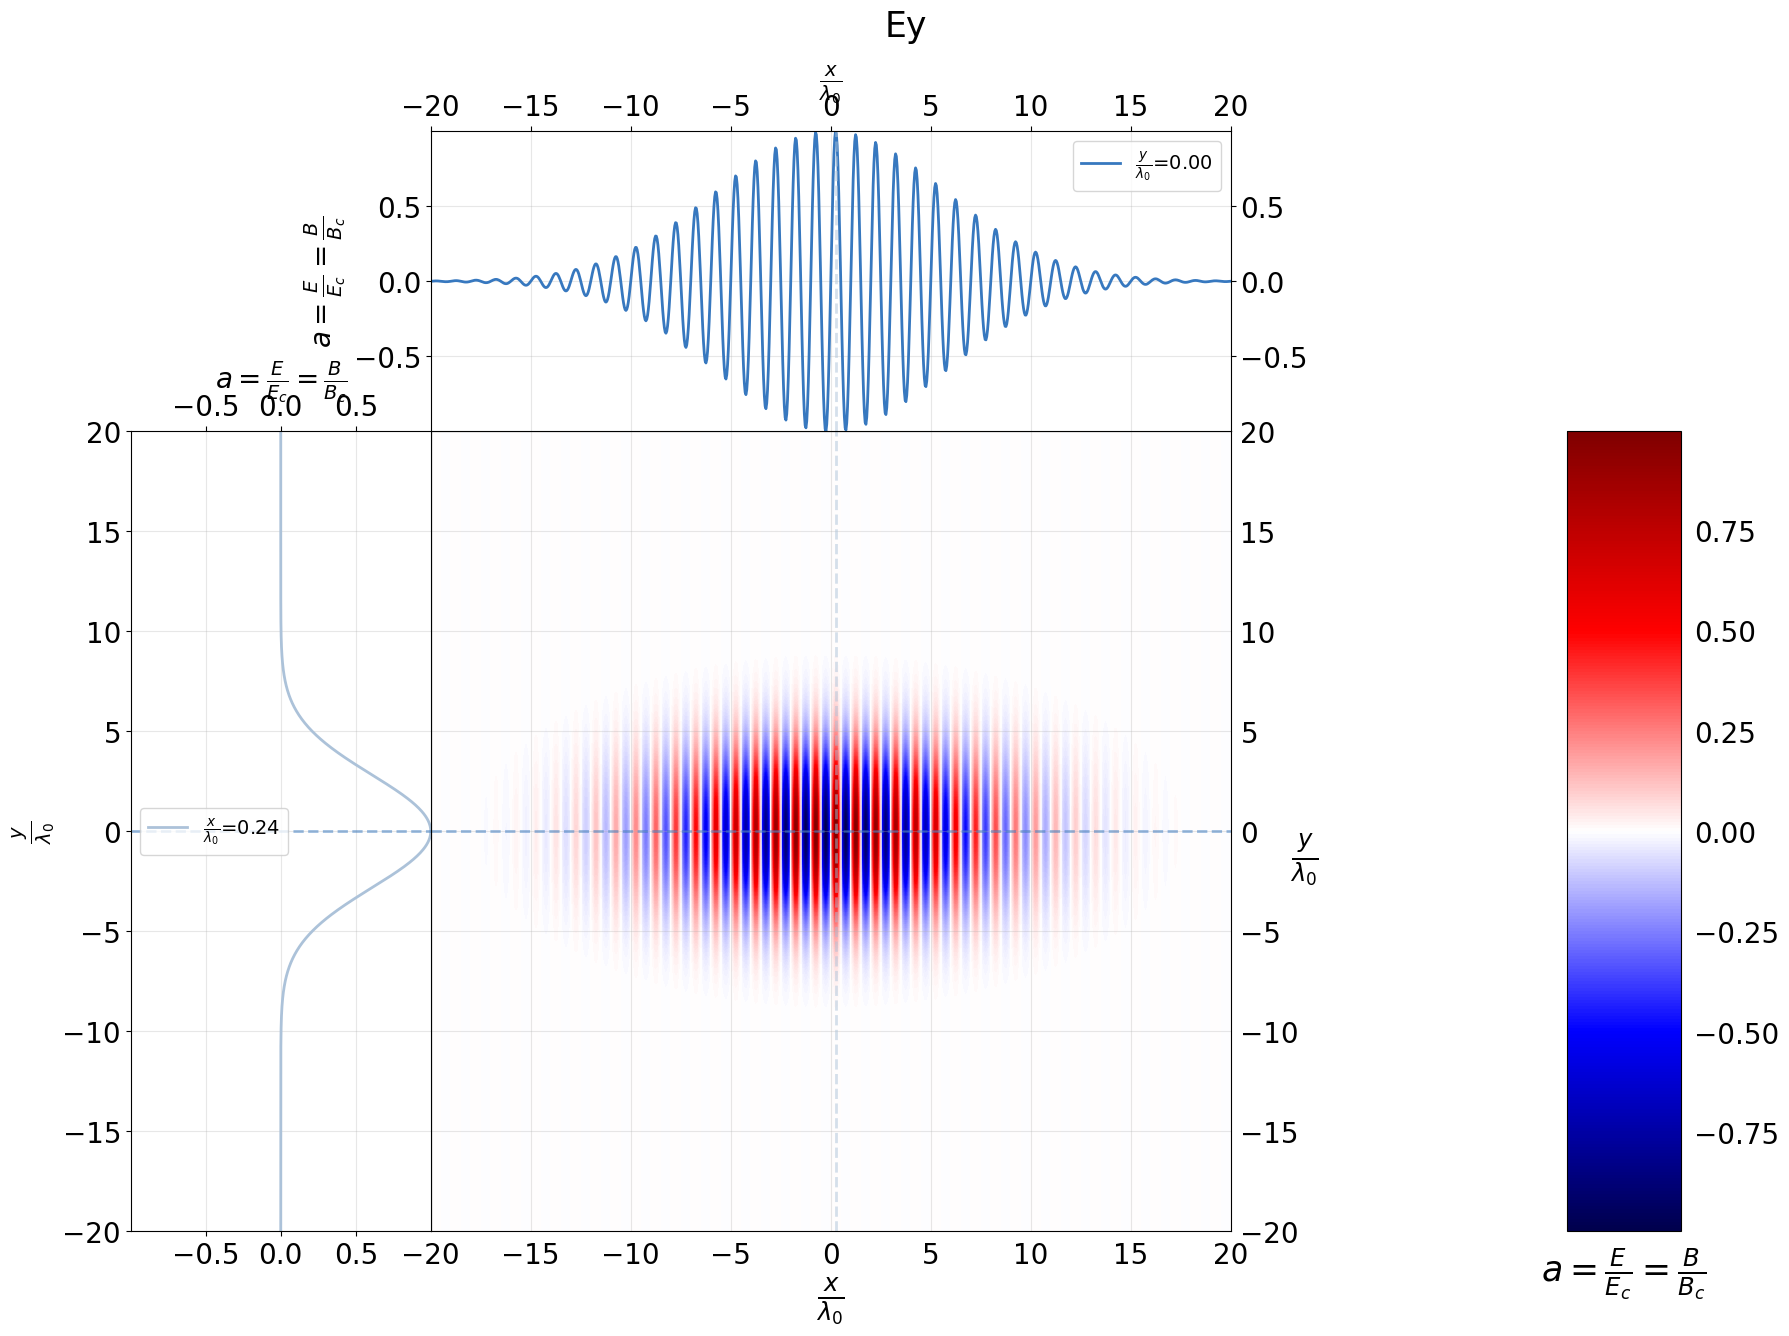

In [3]:
plot_2D_field(field=Ey[:,:,0],x_coordinate=x_coordinate,y_coordinate=y_coordinate,name='Ey')

In [4]:
Ey_spectrum, k_coordinate_each_axis, pad_slices=get_spectrum_from_field_with_coordinate(
    field=Ey,
    axis=(0,1),
    r_coordinate_each_axis=(x_coordinate,y_coordinate)
)

Pad widths for each axis: [(507, 508), (507, 508), (0, 0)]
Input shape: (1001, 1001, 1)
Output padded shape: (2016, 2016, 1)


In [5]:
print(Ey_spectrum.shape)

(2016, 2016, 1)


In [6]:
kx_coordinate,ky_coordinate=k_coordinate_each_axis

figure size= [18.5 14. ] inch
ax_main position= Bbox(x0=0.24324324324324326, y0=0.10714285714285714, x1=0.6756756756756757, y1=0.6785714285714285)


{'fig': <Figure size 1850x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='kx', ylabel='ky'>,
 'ax_panel_top': <Axes: xlabel='kx', ylabel='I(kx,ky)'>,
 'ax_panel_left': <Axes: xlabel='I(kx,ky)', ylabel='ky'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x14664c127750>}

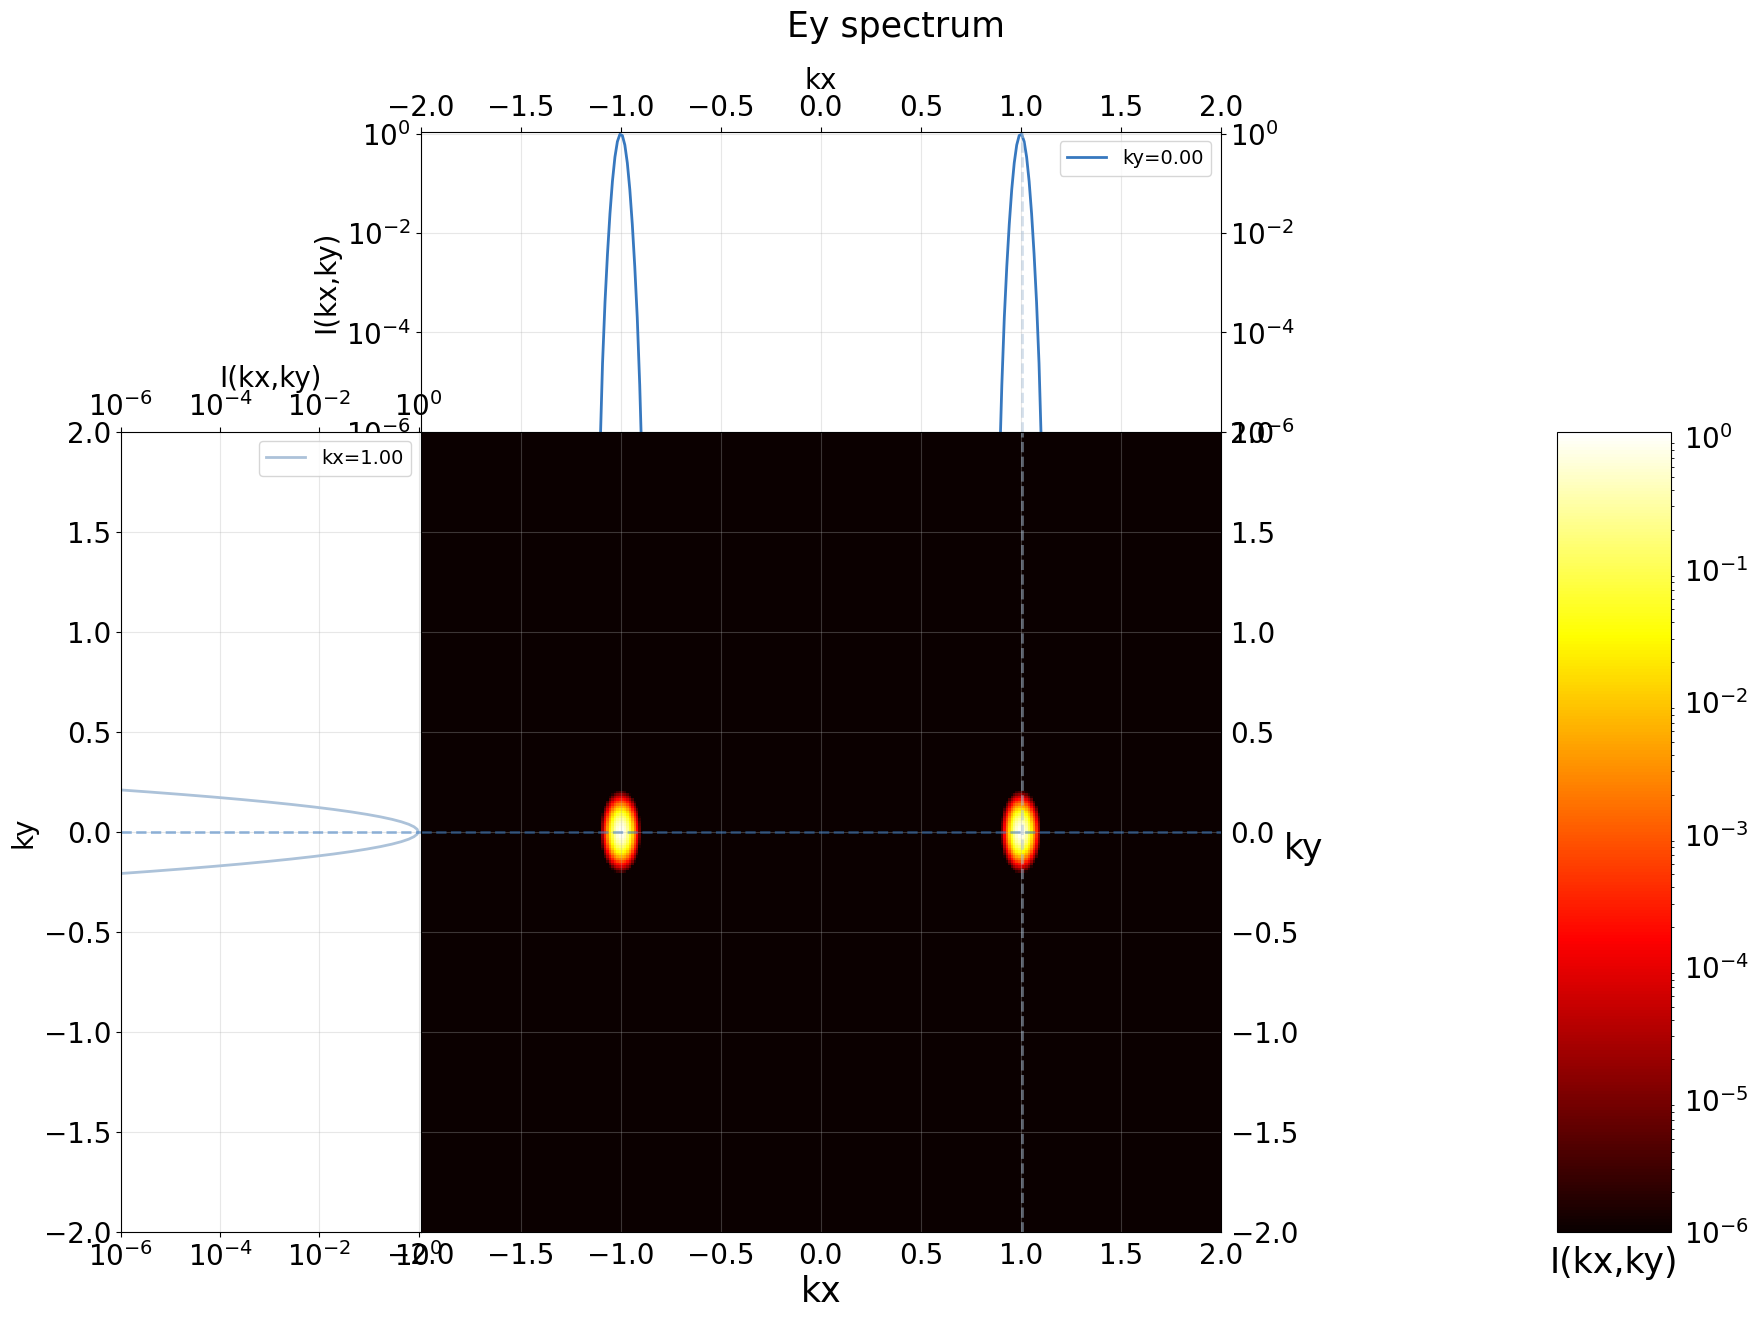

In [7]:
plot_2D_spectrum(
    spectrum_square=jnp.abs(Ey_spectrum[:,:,0])**2/spectrum_peak**2,
    kx_coordinate=kx_coordinate/k0,
    ky_coordinate=ky_coordinate/k0,
    kxmin=-2,
    kxmax=2,
    kymin=-2,
    kymax=2,
    name='Ey spectrum'
)

In [8]:
rotation=Rotation(psi=np.pi/4)

Rotation with angles (phi, psi, theta)=(0.0, 0.7853981633974483, 0.0) radians initialized.


In [11]:
Ex_rotate_spectrum,Ey_rotate_spectrum,Ez_rotate_spectrum=rotation.rotate_r_space(A=jnp.stack([jnp.zeros_like(Ey_spectrum),Ey_spectrum,jnp.zeros_like(Ey_spectrum)]),x0_coordinate=kx_coordinate,y0_coordinate=ky_coordinate,z0_coordinate=[0])

Input field shape: (3, 2016, 2016, 1), Output field shape: (3, 2016, 2016, 1)
∬|Field|^2×dr=992.1978596763364
Input field integral: 992.1978596763364
∬|Field|^2×dr=973.03102412469
Output field integral: 973.03102412469
Integral ratio I1/I0: 0.9806824461827616


figure size= [18.5 14. ] inch
ax_main position= Bbox(x0=0.24324324324324326, y0=0.10714285714285714, x1=0.6756756756756757, y1=0.6785714285714285)


{'fig': <Figure size 1850x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='kx', ylabel='ky'>,
 'ax_panel_top': <Axes: xlabel='kx', ylabel='I(kx,ky)'>,
 'ax_panel_left': <Axes: xlabel='I(kx,ky)', ylabel='ky'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x14664c308e90>}

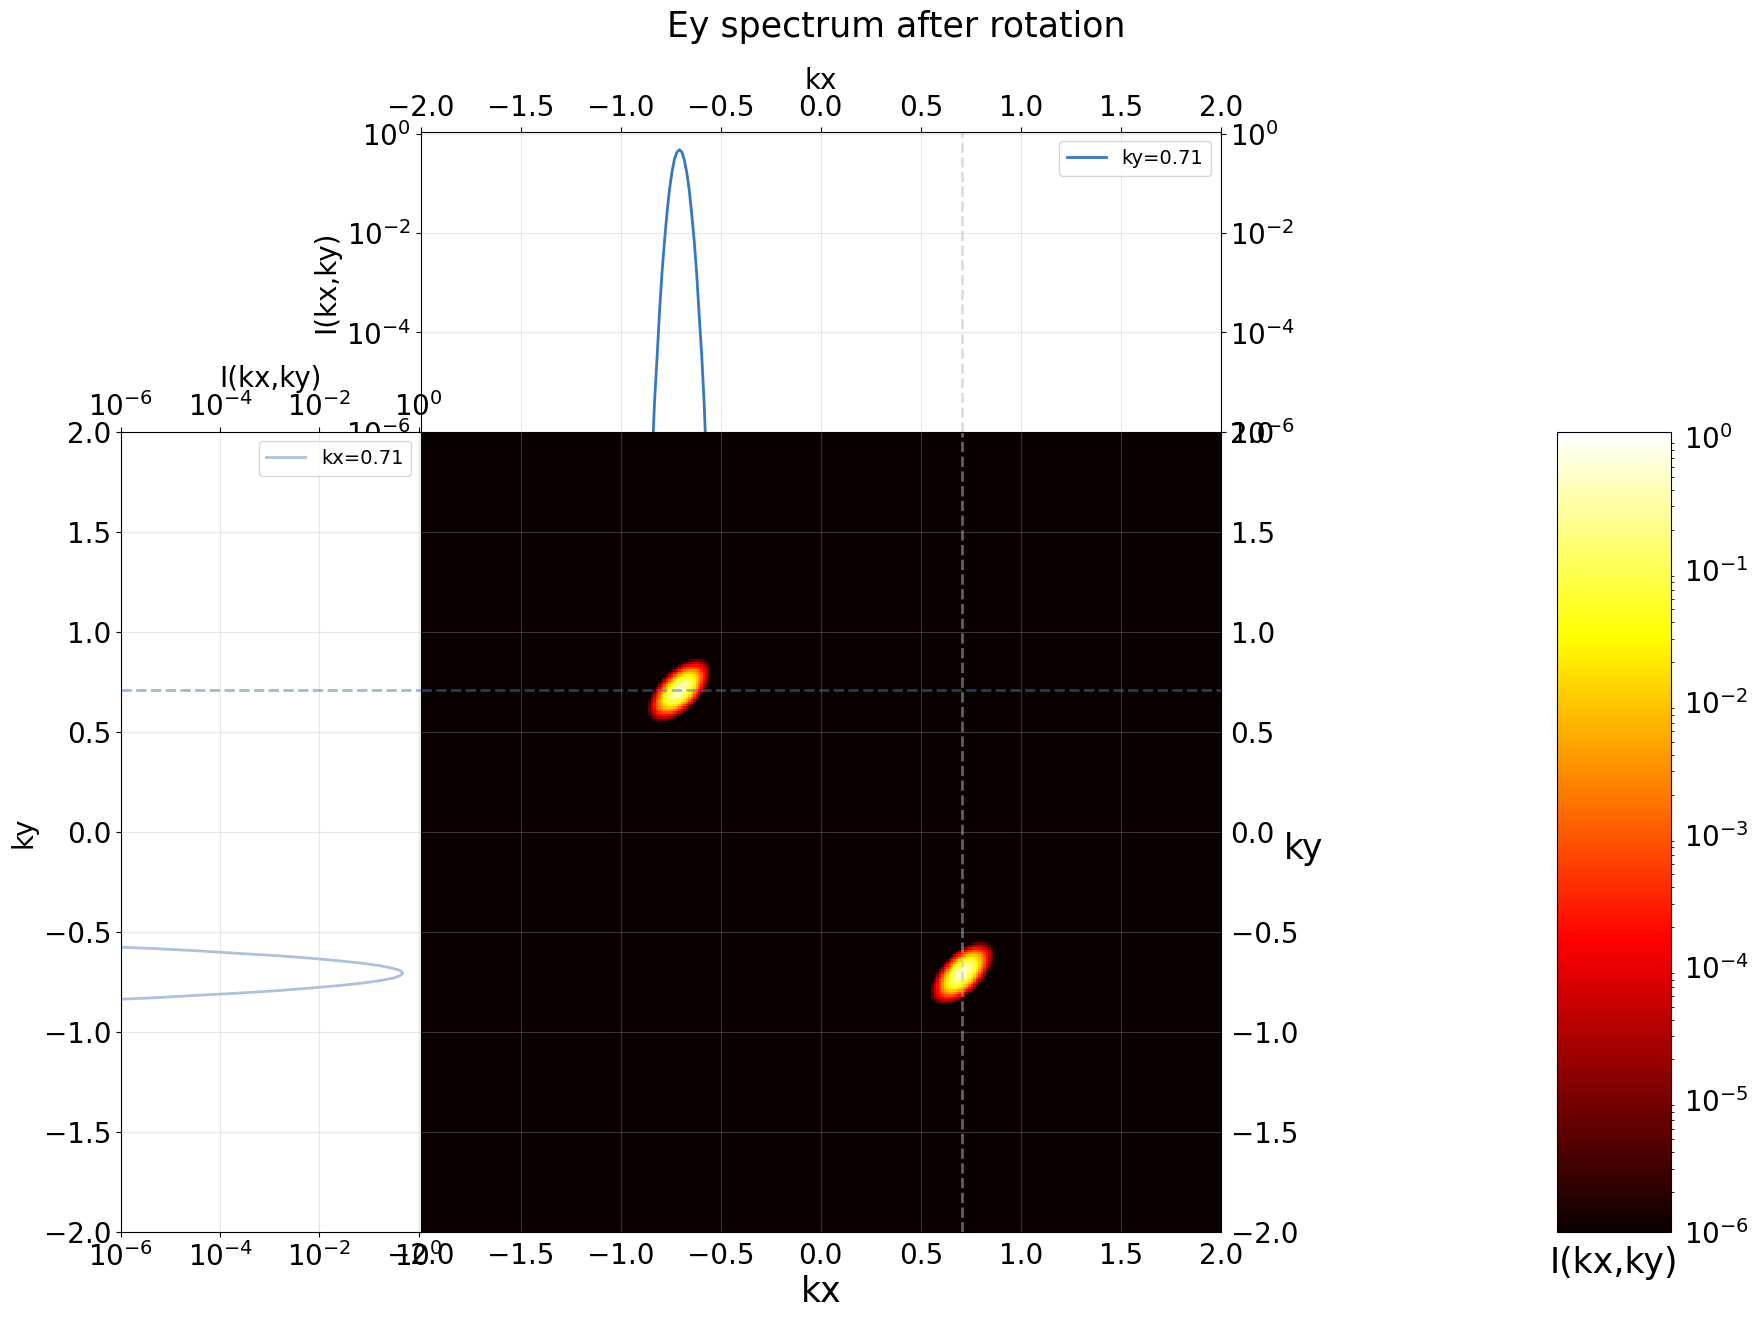

In [13]:
plot_2D_spectrum(
    spectrum_square=jnp.abs(Ey_rotate_spectrum[:,:,0])**2/spectrum_peak**2,
    kx_coordinate=kx_coordinate/k0,
    ky_coordinate=ky_coordinate/k0,
    kxmin=-2,
    kxmax=2,
    kymin=-2,
    kymax=2,
    profile_at_x=1/jnp.sqrt(2),profile_at_y=1/jnp.sqrt(2),
    name='Ey spectrum after rotation'
)

In [15]:
Ey_rotate=get_field_from_spectrum_with_coordinate(
    spectrum=Ey_rotate_spectrum,
    axis=(0,1),
    k_coordinate_each_axis=(kx_coordinate,ky_coordinate),
    pad_slices=pad_slices)
Ex_rotate=get_field_from_spectrum_with_coordinate(
    spectrum=Ex_rotate_spectrum,
    axis=(0,1),
    k_coordinate_each_axis=(kx_coordinate,ky_coordinate),
    pad_slices=pad_slices)

figure size= [18.5 14. ] inch
ax_main position= Bbox(x0=0.24324324324324326, y0=0.10714285714285714, x1=0.6756756756756757, y1=0.6785714285714285)


{'fig': <Figure size 1850x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_panel_top': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>,
 'ax_panel_left': <Axes: xlabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x146c39605fd0>}

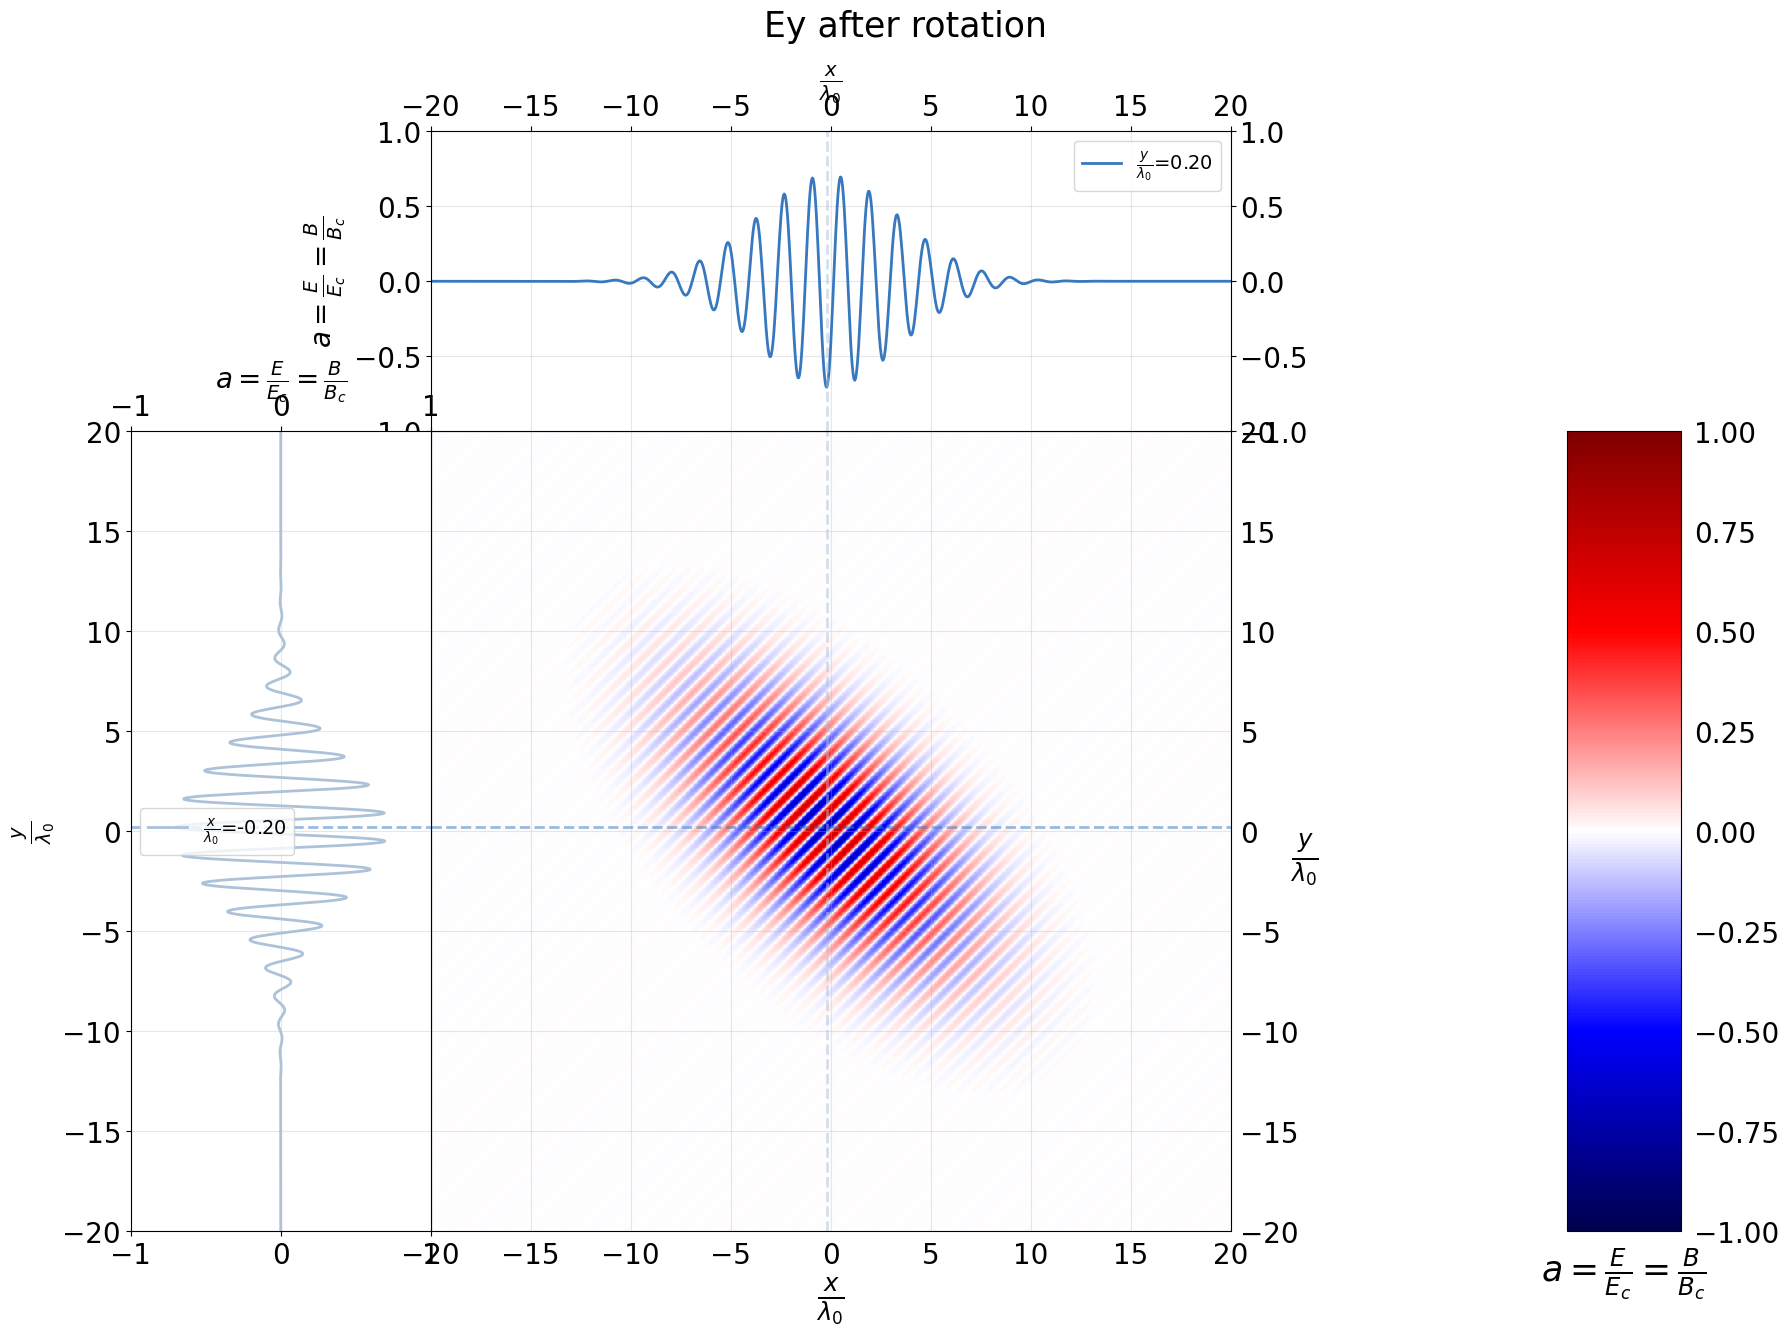

In [17]:
plot_2D_field(
    field=Ey_rotate[:,:,0],x_coordinate=x_coordinate,y_coordinate=y_coordinate,name='Ey after rotation',
    vmin=-1,vmax=1)